![](https://i.pinimg.com/originals/1e/0a/8c/1e0a8c05fa4735cbfc94c8fa337b305c.gif)

<div class="alert alert-block alert-info" style="font-size:20px; background-color: #cf6161; font-family:verdana; color: #701212; border: 3px #701212 solid">
    <b>💊 Medical Instance Segmentation with YOLOv8</b>
    <br>Hi all! 👨‍⚕️<br>
    Today we will dive into the problem of segmentation of instances in a medical context, and we will also use the YOLOv8 model, which is SOTA today. I hope you can learn something new.
</div>

![](https://i.pinimg.com/originals/62/3e/2f/623e2feebd36f364f704865c7603249d.gif)

<div class="alert alert-block alert-info" style="font-size:20px; background-color: #d1a6ff; font-family:verdana; color: #533078; border: 3px #533078 solid">
    <b>Biological overview ⚕️</b>
    <br>Our task is to segment medical images of kidney tissue samples. Human tissues are covered with many vessels. Our task is to segment such vessels.<br>
</div>

![](https://i.ibb.co/1MZNhNF/003.png)

<div class="alert alert-block alert-info" style="font-size:20px; background-color: #d1a6ff; font-family:verdana; color: #533078; border: 2px #533078 solid">
    <b>Tissue samples 🧪</b>
    <br>Renal cortex: the renal cortex is the outer portion of the kidney that contains round renal corpuscles enclosing glomerular tufts, balls of capillary loops. The renal corpuscle is the start of the nephron, through which the filtration of blood occurs. The renal cortex also contains proximal and distal convoluted tubules, PCTs and DCTs, which are also regions of the nephron. Between these tubular structures is a complex network of capillaries called the peritubular capillaries.<br>
    <br>Renal medulla: the renal medulla is the inner portion of the kidney and is arranged in 8-15 renal pyramids containing linearly arranged tubules comprising the loops of Henle and ducts that gather products for excretion. The capillary network in the renal medulla consists of capillaries called vasa recta. The renal pyramids (medullary tissue) are divided by extensions of the renal cortex called renal columns. There are also projections of the renal medulla into the outer cortex called medullary rays.<br>
    <br>Renal papilla (subsection of medulla): the broad bases of the pyramids connect to the renal cortex at the corticomedullary junctions while the tips form structures called the renal papilla, which project in the minor renal calyces where urine is collected.<br>
</div>

<div class="alert alert-block alert-info" style="font-size:20px; background-color: #b5e1ff; font-family:verdana; color: #011d82; border: 2px #011d82 solid">
    <b>What is instance segmentation?</b>
    <br>Instance Segmentation is a unique form of image segmentation that deals with detecting and delineating each distinct instance of an object appearing in an image. Instance segmentation detects all instances of a class with the extra functionality of demarcating separate instances of any segment class. Hence, it is also referred to as incorporating object detection and semantic segmentation functionality. Watch video to learn more: <a href=instance segmentation>Instance segmentation | Tutorial</a> <br>
</div>

<div class="alert alert-block alert-info" style="font-size:20px; background-color: #b5e1ff; font-family:verdana; color: #011d82; border: 2px #011d82 solid">
    <b>Applications of Semantic Segmentation</b>
<ol><li><strong>Medical Diagnostics: </strong>For detecting medical abnormalities in <a href="https://universe.roboflow.com/search?q=xray&amp;ref=blog.roboflow.com">X-Rays, CT Scans, MRI Scans</a></li><li><strong>GeoSensing:</strong> For land usage mapping from <a href="https://roboflow.com/solutions/aerial?ref=blog.roboflow.com">satellite imagery</a> and monitoring areas of deforestation and urbanization</li><li><strong>Autonomous Driving:</strong> For accurately <a href="https://universe.roboflow.com/browse/self-driving?ref=blog.roboflow.com">detecting lanes, pedestrians, traffic signs, road</a>, sky and other vehicles on the road</li></ol><br>
</div>



# Prepare data
<div class="alert alert-block alert-info" style="font-size:20px; background-color: #abffd1; font-family:verdana; color: #003819; border: 2px #003819 solid">
    <b>It's time to think about data 📚</b>
    <br>For training, we need a dataset, and not just any, but in the COCO format. COCO is an open database for object detection, it is huge and therefore it is used all over the world to evaluate new models according to various metrics. It plays a rather important role, and most detection models are pre-trained on it. That is why this dataset format is used in ultralytics. You don't need to worry about this, as I have already prepared a class for data processing. I advise you to skip the cell below and immediately proceed to the next chapter.<br>
</div>

<div class="alert alert-block alert-info" style="font-size:20px; background-color: #abffd1; font-family:verdana; color: #003819; border: 2px #003819 solid">
    <b>Libraries for creating dataset</b>
</div>

In [1]:
from itertools import chain
import json
import os
import shutil
from tqdm.notebook import tqdm
from colorama import Fore
import yaml
import numpy as np

<div class="alert alert-block alert-info" style="font-size:20px; background-color: #abffd1; font-family:verdana; color: #003819; border: 2px #003819 solid">
    <b>Class for creating dataset</b>
</div>

In [2]:
class COCODataset:
    def __init__(self, images_dirpath: str, annotations_filepath: str, length: int = 1633):
        self.train_size = None
        self.val_size = None
        self.length = length
        self.classes = None
        self.labels_counter = None
        self.normalize = None
        
        self.images_dirpath = images_dirpath
        self.annotations_filepath = annotations_filepath
        self.dataset_dirpath = os.path.join(os.getcwd(), "dataset")
        self.train_dirpath =  os.path.join(self.dataset_dirpath, "train")
        self.val_dirpath =  os.path.join(self.dataset_dirpath, "val")
        self.config_path = os.path.join(self.dataset_dirpath, "coco.yaml")

        self.samples = self.parse_jsonl(annotations_filepath)
        self.classes_dict = {
            "blood_vessel": 0,
            "glomerulus": 1,
            "unsure": 2,
        }

    def __prepare_dirs(self) -> None:
        if not os.path.exists(self.dataset_dirpath):
            os.makedirs(os.path.join(self.train_dirpath, "images"), exist_ok=True)
            os.makedirs(os.path.join(self.train_dirpath, "labels"), exist_ok=True)
            os.makedirs(os.path.join(self.val_dirpath, "images"), exist_ok=True)
            os.makedirs(os.path.join(self.val_dirpath, "labels"), exist_ok=True)
        else:
            raise RuntimeError("Dataset already exists!")

    def __define_splitratio(self) -> None:
        self.train_size = round(self.length * self.train_size)
        self.val_size = self.length - self.train_size
        assert self.train_size + self.val_size == self.length

    def parse_jsonl(self, path: str) -> list[dict, ...]:
        with open(path, 'r') as json_file:
            jsonl_samples = [
                json.loads(line)
                for line in tqdm(
                    json_file, desc="Processing polygons", total=self.length
                )
            ]
        return jsonl_samples

    def __define_paths(self, i: int) -> dict:
        data_path = self.val_dirpath
        if i < self.train_size:
            data_path = self.train_dirpath
        return {
            "images": os.path.join(data_path, "images"),
            "labels": os.path.join(data_path, "labels")
        }

    @staticmethod
    def __get_label_path(paths_dict: dict, identifier: str) -> str:
        return os.path.join(
            paths_dict["labels"],
            f"{identifier}.txt"
        )

    @staticmethod
    def __get_image_path(paths_dict: dict, identifier: str) -> str:
        return os.path.join(
            paths_dict["images"],
            f"{identifier}.tif"
        )

    def __copy_image(self, dst_path: str, identifier: str) -> str:
        shutil.copyfile(
            os.path.join(self.images_dirpath, f"{identifier}.tif"),
            dst_path
        )

    def __copy_label(self, annotations: list, dst_path: str) -> None:
        with open(dst_path, "w") as file:
            for annotation in annotations:
                coordinates = annotation["coordinates"][0]
                label = self.classes_dict[annotation["type"]]
                if label in self.classes:
                    if coordinates:
                        if self.normalize:
                            coordinates = np.array(coordinates) / 512.0
                        coordinates = " ".join(map(str, chain(*coordinates)))
                        file.write(f"{label} {coordinates}\n")
                        self.labels_counter += 1

    def __splitfolders(self):
        for i, line in tqdm(
                enumerate(self.samples),
                desc="Dataset creation", total=self.length
        ):
            self.labels_counter = 0
            identifier = line["id"]
            annotations = line["annotations"]
            paths_dict = self.__define_paths(i)

            dst_image_path = self.__get_image_path(paths_dict, identifier)
            dst_label_path = self.__get_label_path(paths_dict, identifier)

            self.__copy_image(dst_image_path, identifier)
            self.__copy_label(annotations, dst_label_path)

            if self.labels_counter == 0:
                os.remove(dst_image_path)
                os.remove(dst_label_path)

    def __count_dataset(self) -> dict:
        train_images = len(os.listdir(os.path.join(self.train_dirpath, "images")))
        train_labels = len(os.listdir(os.path.join(self.train_dirpath, "labels")))
        val_images = len(os.listdir(os.path.join(self.val_dirpath, "images")))
        val_labels = len(os.listdir(os.path.join(self.val_dirpath, "labels")))
        return {
            "train_images": train_images,
            "train_labels": train_labels,
            "val_images": val_images,
            "val_labels": val_labels
        }

    @staticmethod
    def __check_sanity(count_dict: dict) -> None:
        assert count_dict["train_images"] == count_dict["train_labels"]
        assert count_dict["val_images"] == count_dict["val_labels"]

    def __finalizing(self, count_dict: dict) -> None:
        assert os.path.exists(self.dataset_dirpath)

        example_structure = [
            "dataset",
            "train", "labels", "images",
            "val", "labels", "images"
        ]

        dir_bone = (
            dirname.split("/")[-1]
            for dirname, _, filenames in os.walk(self.dataset_dirpath)
            if dirname.split("/")[-1] in example_structure
        )

        try:
            print("\n~ HuBMAP Dataset Structure ~\n")
            print(
            f"""
          ├── {next(dir_bone)}
          │   │
          │   ├── {next(dir_bone)}
          │   │   └── {next(dir_bone)}
          │   │   └── {next(dir_bone)}
          │   │
          │   ├── {next(dir_bone)}
          │   │   └── {next(dir_bone)}
          │   │   └── {next(dir_bone)}
            """
            )
        except StopIteration as e:
            print(e)
        else:
            print(Fore.GREEN + "-> Success")
            print(Fore.GREEN + f"Train dataset: {count_dict['train_images']}\nVal dataset: {count_dict['val_images']}")

    def get_config(self) ->dict:
        names = ["blood_vessel", "glomerulus", "unsure"]
        return {
            "train": str(self.train_dirpath),
            "val": str(self.val_dirpath),
            "names": [names[i] for i in self.classes]
        }

    @staticmethod
    def display_config(config: dict) -> None:
        print(Fore.BLACK + "\n~ HuBMAP Config Structure ~\n")
        print(
        f"""
      │   │
      │   ├── train
      │   │   └── {config['train']}/images
      │   │
      │   │
      │   ├── val
      │   │   └── {config['val']}/images
      │   │
      │   │
      │   ├── names
      │   │   └── {' '.join(config['names'])}
        """
        )
        print(Fore.GREEN + "-> Success")
        print(Fore.GREEN + f"Number of classes: {len(config['names'])}"
                           f"\nClasses: {' '.join(config['names'])}" 
              )

    def write_config(self, config: dict) -> None:
        with open(self.config_path, mode="w") as f:
            yaml.safe_dump(stream=f, data=config)

    def __call__(self, train_size: float,
                 classes: list[int, ...],
                 make_config: bool = True,
                 normalize: bool = True
                ) -> None:
        
        self.train_size = train_size
        self.classes = classes
        self.normalize = normalize
        
        self.__define_splitratio()
        self.__prepare_dirs()
        self.__splitfolders()
        count_dict = self.__count_dataset()
        self.__check_sanity(count_dict)
        self.__finalizing(count_dict)
        
        if make_config:
            config = self.get_config()
            self.write_config(config)
            self.display_config(config)

<div class="alert alert-block alert-info" style="font-size:20px; background-color: #abffd1; font-family:verdana; color: #003819; border: 2px #003819 solid">
    <b>Let's fire up the data 🔥</b>
</div>

In [3]:
coco = COCODataset(
    annotations_filepath="/kaggle/input/hubmap-hacking-the-human-vasculature/polygons.jsonl",
    images_dirpath="/kaggle/input/hubmap-hacking-the-human-vasculature/train",
) 

Processing polygons:   0%|          | 0/1633 [00:00<?, ?it/s]

In [4]:
coco(train_size=0.80, classes=[0, 1, 2])

Dataset creation:   0%|          | 0/1633 [00:00<?, ?it/s]


~ HuBMAP Dataset Structure ~


          ├── dataset
          │   │
          │   ├── val
          │   │   └── images
          │   │   └── labels
          │   │
          │   ├── train
          │   │   └── images
          │   │   └── labels
            
-> Success
Train dataset: 1306
Val dataset: 327

~ HuBMAP Config Structure ~


      │   │
      │   ├── train
      │   │   └── /kaggle/working/dataset/train/images
      │   │
      │   │
      │   ├── val
      │   │   └── /kaggle/working/dataset/val/images
      │   │
      │   │
      │   ├── names
      │   │   └── blood_vessel glomerulus unsure
        
-> Success
Number of classes: 3
Classes: blood_vessel glomerulus unsure


<div class="alert alert-block alert-info" style="font-size:20px; background-color: #f2ffb0; font-family:verdana; color: #3c450e; border: 2px #3c450e solid">
    <b>And how can I use the right tools if the internet is banned in the competition? 🙁</b>
    <br>In the competition, many have difficulty installing the necessary tools and using them, because the Internet is prohibited, but it is prohibited only so that the test data is not stolen (they are uploaded to the test folder during the submission of the result). This means that you can use the tools you want, but you must add them as data. You can find my ultralytics and pycocotools dataset here. Importantly, the Internet is still present in this notebook to load the model, however, after training it, you will save the model, add it to the data and easily use it for forecasting without the Internet.<br>
</div>

In [5]:
import shutil
import os
import sys
from colorama import Fore

In [6]:
class SetupPipline:
    def __init__(self, display: bool = True):
        self.pycocotools = self.__pycocotools()
        self.ultralytics = self.__ultralytics()
        
    @staticmethod
    def __ultralytics() -> str:
        sys.path.append("/kaggle/input/hubmap-tools-ultralytics-and-pycocotools/ultralytics/ultralytics") 
        return "successfully"
        
    @staticmethod
    def __pycocotools() -> str:
        if not os.path.exists("/kaggle/working/packages"):
            shutil.copytree("/kaggle/input/hubmap-tools-ultralytics-and-pycocotools/pycocotools/pycocotools", "/kaggle/working/packages")
            os.chdir("/kaggle/working/packages/pycocotools-2.0.6/")
            os.system("python setup.py install")
            os.system("pip install . --no-index --find-links /kaggle/working/packages/")
            os.chdir("/kaggle/working")
            return "successfully"
    
    def display(self) -> None:
        print(Fore.GREEN+f"\nPycocotools was installed {self.pycocotools}")
        print(f"Ultralytics was installed {self.ultralytics}"+Fore.WHITE)

In [7]:
pipline = SetupPipline()

running install


/opt/conda/lib/python3.10/site-packages/setuptools/command/install.py:34: SetuptoolsDeprecationWarning: setup.py install is deprecated. Use build and pip and other standards-based tools.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/setuptools/command/easy_install.py:156: EasyInstallDeprecationWarning: easy_install command is deprecated. Use build and pip and other standards-based tools.
  warnings.warn(


running bdist_egg
running egg_info
writing pycocotools.egg-info/PKG-INFO
writing dependency_links to pycocotools.egg-info/dependency_links.txt
writing requirements to pycocotools.egg-info/requires.txt
writing top-level names to pycocotools.egg-info/top_level.txt
reading manifest file 'pycocotools.egg-info/SOURCES.txt'
reading manifest template 'MANIFEST.in'
writing manifest file 'pycocotools.egg-info/SOURCES.txt'
installing library code to build/bdist.linux-x86_64/egg
running install_lib
running build_py
creating build
creating build/lib.linux-x86_64-3.10
creating build/lib.linux-x86_64-3.10/pycocotools
copying pycocotools/cocoeval.py -> build/lib.linux-x86_64-3.10/pycocotools
copying pycocotools/coco.py -> build/lib.linux-x86_64-3.10/pycocotools
copying pycocotools/__init__.py -> build/lib.linux-x86_64-3.10/pycocotools
copying pycocotools/mask.py -> build/lib.linux-x86_64-3.10/pycocotools
running build_ext
cythoning pycocotools/_mask.pyx to pycocotools/_mask.c


/opt/conda/lib/python3.10/site-packages/Cython/Compiler/Main.py:369: FutureWarning: Cython directive 'language_level' not set, using 2 for now (Py2). This will change in a later release! File: /kaggle/working/packages/pycocotools-2.0.6/pycocotools/_mask.pyx
  tree = Parsing.p_module(s, pxd, full_module_name)


building 'pycocotools._mask' extension
creating build/temp.linux-x86_64-3.10
creating build/temp.linux-x86_64-3.10/common
creating build/temp.linux-x86_64-3.10/pycocotools
gcc -pthread -B /opt/conda/compiler_compat -Wno-unused-result -Wsign-compare -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /opt/conda/include -fPIC -O2 -isystem /opt/conda/include -fPIC -I/opt/conda/lib/python3.10/site-packages/numpy/core/include -I./common -I/opt/conda/include/python3.10 -c ./common/maskApi.c -o build/temp.linux-x86_64-3.10/./common/maskApi.o -Wno-cpp -Wno-unused-function -std=c99


...

gcc -pthread -B /opt/conda/compiler_compat -Wno-unused-result -Wsign-compare -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /opt/conda/include -fPIC -O2 -isystem /opt/conda/include -fPIC -I/opt/conda/lib/python3.10/site-packages/numpy/core/include -I./common -I/opt/conda/include/python3.10 -c pycocotools/_mask.c -o build/temp.linux-x86_64-3.10/pycocotools/_mask.o -Wno-cpp -Wno-unused-function -std=c99


pycocotools/_mask.c: In function ‘__pyx_pf_11pycocotools_5_mask_12iou’:
pycocotools/_mask.c:6140:31: warning: comparison of integer expressions of different signedness: ‘Py_ssize_t’ {aka ‘long int’} and ‘siz’ {aka ‘long unsigned int’} [-Wsign-compare]
 6140 |     if (unlikely(!((__pyx_t_8 == __pyx_v_n) != 0))) {
      |                               ^~
pycocotools/_mask.c:944:43: note: in definition of macro ‘unlikely’
  944 |   #define unlikely(x) __builtin_expect(!!(x), 0)
      |                                           ^


gcc -pthread -B /opt/conda/compiler_compat -shared -Wl,--allow-shlib-undefined -Wl,-rpath,/opt/conda/lib -Wl,-rpath-link,/opt/conda/lib -L/opt/conda/lib -Wl,--allow-shlib-undefined -Wl,-rpath,/opt/conda/lib -Wl,-rpath-link,/opt/conda/lib -L/opt/conda/lib build/temp.linux-x86_64-3.10/./common/maskApi.o build/temp.linux-x86_64-3.10/pycocotools/_mask.o -o build/lib.linux-x86_64-3.10/pycocotools/_mask.cpython-310-x86_64-linux-gnu.so
creating build/bdist.linux-x86_64
creating build/bdist.linux-x86_64/egg
creating build/bdist.linux-x86_64/egg/pycocotools
copying build/lib.linux-x86_64-3.10/pycocotools/_mask.cpython-310-x86_64-linux-gnu.so -> build/bdist.linux-x86_64/egg/pycocotools
copying build/lib.linux-x86_64-3.10/pycocotools/cocoeval.py -> build/bdist.linux-x86_64/egg/pycocotools
copying build/lib.linux-x86_64-3.10/pycocotools/coco.py -> build/bdist.linux-x86_64/egg/pycocotools
copying build/lib.linux-x86_64-3.10/pycocotools/__init__.py -> build/bdist.linux-x86_64/egg/pycocotools
copying

zip_safe flag not set; analyzing archive contents...
pycocotools.__pycache__._mask.cpython-310: module references __file__
error: [Errno 2] No such file or directory: '/opt/conda/lib/python3.10/site-packages/numpy-1.24.3.dist-info/METADATA'


Looking in links: /kaggle/working/packages/
Processing /kaggle/working/packages/pycocotools-2.0.6
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pycocotools: filename=pycocotools-2.0.6-cp310-cp310-linux_x86_64.whl size=93515 sha256=43eb2cf34479cec8f4fefa8c7ffe825f7c6b3641400004560adaa4426ed59f3b
  Stored in directory: /root/.cache/pip/wheels/b7/83/32/99474500256e64154dfc568319411b6ff49e96e50f30d9474f
Successfully built pycocotools
  Attempting uninstall: pycocotools
    Found existing installation: pycocotools 2.0.6
    Uninstalling pycocotools-2.0.6:
      Successfully uninstalled pycocotools-2.0.6


In [8]:
pipline.display()


Pycocotools was installed successfully
Ultralytics was installed successfully


In [9]:
from pycocotools import _mask as coco_mask 
from ultralytics import YOLO

# Logging
<div class="alert alert-block alert-info" style="font-size:20px; background-color: #eec4ff; font-family:verdana; color: #511b66; border: 2px #511b66 solid">
    <b>And now a little about the control of experiments</b>
    <br>Experiment control tools are a very important part of your pipeline. With the help of them, you can track learning and compare results with previous ones to solve your problem. It is very convenient and allows you not to get confused.<br>
</div>

# ClearML Logging and Automation 🌟 NEW

[ClearML](https://cutt.ly/yolov5-notebook-clearml) is completely integrated into YOLOv5 to track your experimentation, manage dataset versions and even remotely execute training runs. To enable ClearML (check cells above):

- `pip install clearml`
- run `clearml-init` to connect to a ClearML server (**deploy your own [open-source server](https://github.com/allegroai/clearml-server)**, or use our [free hosted server](https://cutt.ly/yolov5-notebook-clearml))

You'll get all the great expected features from an experiment manager: live updates, model upload, experiment comparison etc. but ClearML also tracks uncommitted changes and installed packages for example. Thanks to that ClearML Tasks (which is what we call experiments) are also reproducible on different machines! With only 1 extra line, we can schedule a YOLOv5 training task on a queue to be executed by any number of ClearML Agents (workers).

You can use ClearML Data to version your dataset and then pass it to YOLOv5 simply using its unique ID. This will help you keep track of your data without adding extra hassle. Explore the [ClearML Tutorial](https://github.com/ultralytics/yolov5/tree/master/utils/loggers/clearml) for details!

<a href="https://cutt.ly/yolov5-notebook-clearml">
<img alt="ClearML Experiment Management UI" src="https://github.com/thepycoder/clearml_screenshots/raw/main/scalars.jpg" width="1280"/></a>

# Weights and biases
  
 <p align='center'> 
 <a href="https://pypi.python.org/pypi/wandb"><img src="https://img.shields.io/pypi/v/wandb" /></a> 
 <a href="https://anaconda.org/conda-forge/wandb"><img src="https://img.shields.io/conda/vn/conda-forge/wandb" /></a> 
 <a href="https://circleci.com/gh/wandb/wandb"><img src="https://img.shields.io/circleci/build/github/wandb/wandb/main" /></a> 
 <a href="https://codecov.io/gh/wandb/wandb"><img src="https://img.shields.io/codecov/c/gh/wandb/wandb" /></a> 
 </p> 
 <p align='center'> 
 <a href="https://colab.research.google.com/github/wandb/examples/blob/master/colabs/intro/Intro_to_Weights_%26_Biases.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" /></a> 
 </p> 
  
 Use W&B to build better models faster. Track and visualize all the pieces of your machine learning pipeline, from datasets to production machine learning models. Get started with W&B today, [sign up for a free account!](https://wandb.com?utm_source=github&utm_medium=code&utm_campaign=wandb&utm_content=readme) 
  
 🎓 W&B is free for students, educators, and academic researchers. For more information, visit [https://wandb.ai/site/research](https://wandb.ai/site/research?utm_source=github&utm_medium=code&utm_campaign=wandb&utm_content=readme). 
  
 Want to use Weights & Biases for seamless collaboration between your ML or Data Science team? Looking for Production-grade MLOps at scale? Sign up to one of [our plans](https://wandb.ai/site/pricing) or [contact the Sales Team](https://wandb.ai/site/contact).


# YOLOv8 Architecture: A Deep Dive
<div class="alert alert-block alert-info" style="font-size:20px; background-color: #eec4ff; font-family:verdana; color: #511b66; border: 2px #511b66 solid">
YOLOv8 does not yet have a published paper, so we lack direct insight into the direct research methodology and ablation studies done during its creation. With that said, we analyzed the repository and information available about the model to start documenting what's new in YOLOv8.

If you want to peer into the code yourself, check out the YOLOv8 repository and you view this code differential to see how some of the research was done.

Here we provide a quick summary of impactful modeling updates and then we will look at the model's evaluation, which speaks for itself.

The following image made by GitHub user RangeKing shows a detailed visualisation of the network's architecture.
</div>

![](https://blog.roboflow.com/content/images/size/w1000/2023/01/image-16.png)

# Training
<div class="alert alert-block alert-info" style="font-size:20px; background-color: #eec4ff; font-family:verdana; color: #511b66; border: 2px #511b66 solid">
    <b>Finally, we can start learning 🥳</b>
    <br>From this moment begins our greedy search. We hypothesize hypotheses, select hypermaparmeters, train, and then check whether the hypothesis was correct using the resulting metrics. This stage is one of the most interesting. Offhand, I can say that the best results can be obtained on a pre-trained model with the parameters below (well + - still try to experiment)<br>
</div>

In [10]:
def main():
    model = YOLO("yolov8x-seg.pt")
    model.train(
        # Project
        project="HuBMAP",
        name="yolov8x-seg",

        # Random Seed parameters
        deterministic=True,
        seed=43,

        # Data & model parameters
        data="/kaggle/working/dataset/coco.yaml", 
        save=True,
        save_period=5,
        pretrained=True,
        imgsz=512,

        # Training parameters
        epochs=20,
        batch=4,
        workers=8,
        val=True,
        device=0,

        # Optimization parameters
        lr0=0.018,
        patience=3,
        optimizer="SGD",
        momentum=0.947,
        weight_decay=0.0005,
        close_mosaic=3,
    )


<div class="alert alert-block alert-info" style="font-size:20px; background-color: #eec4ff; font-family:verdana; color: #511b66; border: 2px #511b66 solid">
    <b>Please follow the <a href=https://wandb.ai/site>link</a>. Sign up and then paste your API key into the box that pops up below. Do not disclose your key to anyone. Here it is required so that you can track the training</b>
</div>

In [11]:
if __name__ == '__main__':
    main()

100%|██████████| 137M/137M [00:01<00:00, 138MB/s]  
New https://pypi.org/project/ultralytics/8.0.124 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.0.120 🚀 Python-3.10.10 torch-2.0.0 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)
yolo/engine/trainer: task=segment, mode=train, model=yolov8x-seg.pt, data=/kaggle/working/dataset/coco.yaml, epochs=20, patience=3, batch=4, imgsz=512, save=True, save_period=5, cache=False, device=0, workers=8, project=HuBMAP, name=yolov8x-seg, exist_ok=False, pretrained=True, optimizer=SGD, verbose=True, seed=43, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=3, resume=False, amp=True, fraction=1.0, profile=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, vid_stride=1, line_wid

  ········································


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


AMP: running Automatic Mixed Precision (AMP) checks with YOLOv8n...
100%|██████████| 6.23M/6.23M [00:00<00:00, 45.1MB/s]
AMP: checks passed ✅
train: Scanning /kaggle/working/dataset/train/labels... 1306 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1306/1306 [00:05<00:00, 258.26it/s]
train: WARNING ⚠️ /kaggle/working/dataset/train/images/005715f0a313.tif: 1 duplicate labels removed
train: WARNING ⚠️ /kaggle/working/dataset/train/images/01a7fca6263b.tif: 7 duplicate labels removed
train: WARNING ⚠️ /kaggle/working/dataset/train/images/025ec20b8b73.tif: 7 duplicate labels removed
train: WARNING ⚠️ /kaggle/working/dataset/train/images/02cf5c2db152.tif: 1 duplicate labels removed
train: WARNING ⚠️ /kaggle/working/dataset/train/images/033a656390b2.tif: 4 duplicate labels removed
train: WARNING ⚠️ /kaggle/working/dataset/train/images/0672b96aaccc.tif: 4 duplicate labels removed
train: WARNING ⚠️ /kaggle/working/dataset/train/images/07b809228ef4.tif: 4 duplicate labels removed
train: WAR

# Predict

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
<b>The training has come to an end and now it is time to look at the results of the work of the neural network</b>
<ul style="font-size:20px; font-family:verdana; line-height: 1.7em">
    <li>Choose any picture</li>
    <li>Displaying the image</li>
</ul>
</div>

In [12]:
import matplotlib.pyplot as plt
from PIL import Image

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
    <b>Choose any picture</b>
</div>

In [13]:
dirlist = os.listdir("/kaggle/working/dataset/val/images")
print(dirlist[:5])

['e1f6c8a7873e.tif', 'dcea4e9d6726.tif', 'fa7c476fc50c.tif', 'f69c378f6f4f.tif', 'f48f6580655c.tif']


<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
    <b>Displaying the image</b>
</div>


image 1/1 /kaggle/working/../working/dataset/val/images/ed6a92a9410c.tif: 512x512 8 blood_vessels, 1 unsure, 33.5ms
Speed: 2.3ms preprocess, 33.5ms inference, 7.9ms postprocess per image at shape (1, 3, 512, 512)


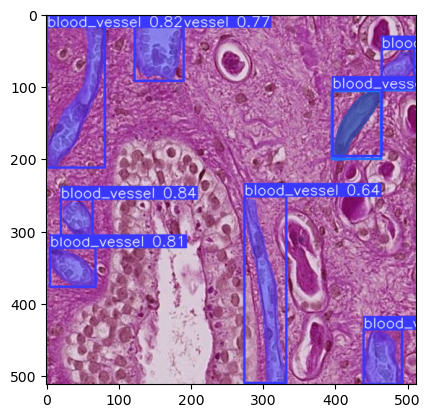

In [14]:
model = YOLO("/kaggle/working/HuBMAP/yolov8x-seg/weights/best.pt")
history = model.predict("../working/dataset/val/images/ed6a92a9410c.tif")[0]
image = history.plot()
plt.imshow(image)
plt.show()

# Let's build the graphs 

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
    <b>Losses & Recall & Precision & mAP</b>
</div>

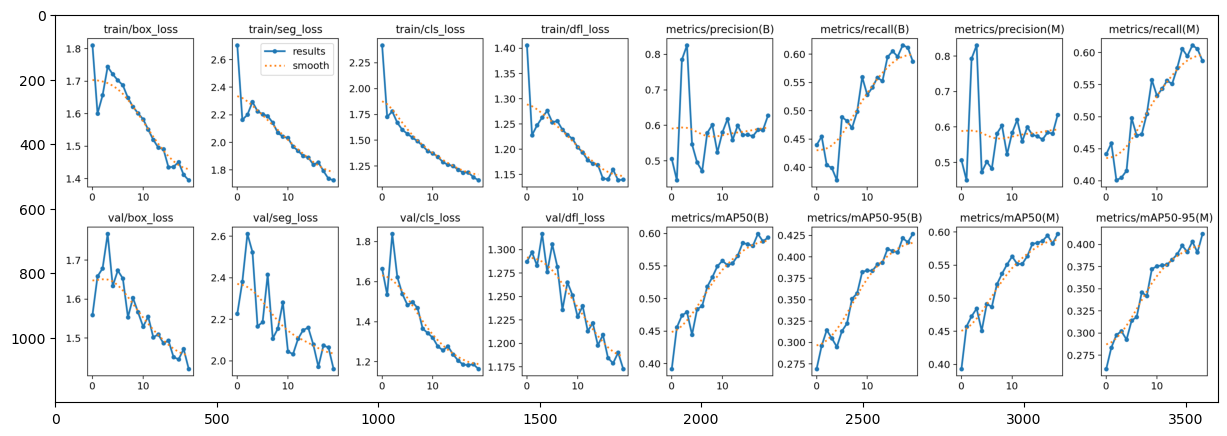

In [15]:
F1_curve = Image.open("/kaggle/working/HuBMAP/yolov8x-seg/results.png")
plt.figure(figsize=(15,20))
plt.imshow(F1_curve)
plt.show()

<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
    <b>Train Batch</b>
</div>

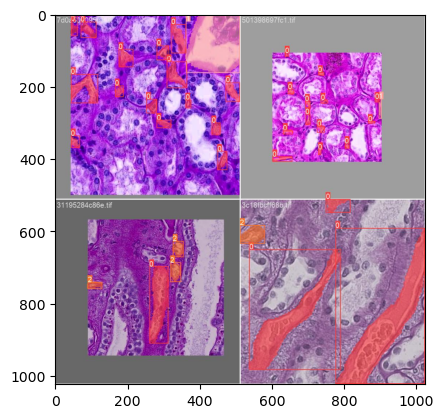

In [16]:
P_curve = Image.open("/kaggle/working/HuBMAP/yolov8x-seg/train_batch5561.jpg")
plt.imshow(P_curve)
plt.show()

<div class="alert alert-block alert-info" style="font-size:20px; background-color: #ffa340; font-family:verdana; color: #663500; border: 2px #663500 solid">
    <b>What about submission? 😸</b>
    <br>We have come a long way, done data analysis, trained the model, but what about the submission? We want to send the results, right? Well, I had difficulties with this, and therefore, in order to make life easier for myself, it is possible to help someone, I wrote several classes that allow you to quickly submit without delving into the difficulties that I encountered.<br>
</div>

<div class="alert alert-block alert-info" style="font-size:20px; background-color: #ffc98f; font-family:verdana; color: #b86e1f; border: 2px #b86e1f solid">
    <b>Encode Binary Mask</b>
</div>

In [17]:
import base64
import numpy as np
import torch
from pycocotools import _mask as coco_mask
import typing as t
import zlib
import pandas as pd
import torchvision.transforms as T
from ultralytics import YOLO
from PIL import Image

In [18]:
class EncodeBinaryMask:
    @staticmethod
    def __checking_mask(mask: np.ndarray) -> np.ndarray:
        if mask.dtype != np.bool:
            raise ValueError(
                "expects a binary mask, received dtype == %s" %
                mask.dtype
            )
        return mask

    @staticmethod
    def __convert_mask(mask: np.ndarray):
        mask_to_encode = mask.astype(np.uint8)
        mask_to_encode = np.asfortranarray(mask_to_encode)
        return mask_to_encode

    @staticmethod
    def __compress_encode(encoded_mask) -> t.Text:
        binary_str = zlib.compress(encoded_mask, zlib.Z_BEST_COMPRESSION)
        base64_str = base64.b64encode(binary_str)
        return base64_str

    def __call__(self, mask: np.ndarray) -> t.Text:
        mask = self.__checking_mask(mask)
        mask_to_encode = self.__convert_mask(mask)
        encoded_mask = coco_mask.encode(mask_to_encode)[0]["counts"]
        base64_str = self.__compress_encode(encoded_mask)
        return base64_str

<div class="alert alert-block alert-info" style="font-size:20px; background-color: #ffc98f; font-family:verdana; color: #b86e1f; border: 2px #b86e1f solid">
    <b>Submission</b>
</div>

In [19]:
class Submission:
    def __init__(self, dirpath: str, model: torch.nn.Module):
        self.__eval_transforms = self.get_transforms()
        self.__model = model
        self.__encoder = EncodeBinaryMask()
        self.__dirpath = dirpath
        self.__filenames = os.listdir(dirpath)
        self.height = 512
        self.width = 512
        
        self.__submission_dict = {
            "id": [],
            "height": [],
            "width": [],
            "prediction_string": []
        }
        
        self.submission = None
    
    @staticmethod
    def get_transforms():
        return T.Compose([
            T.ToTensor(),
            T.Resize(size=(512, 512)),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.__filenames)

    def __get_columns(self) -> None:
        for filename in self.__filenames:
            path = self.__get_image_path(filename)
            masks = self.__forward(path)
            identifier, height, width, prediction_string = self.__get_cells(filename, masks)
            self.__update_columns(identifier, height, width, prediction_string)

    def __update_columns(self, identifier: str, height: int, width: int, prediction_string: str) -> None:
        self.__submission_dict["id"].append(identifier)
        self.__submission_dict["height"].append(height)
        self.__submission_dict["width"].append(width)
        self.__submission_dict["prediction_string"].append(prediction_string)

    def __get_cells(self, filename: str, masks: list):
        prediction_string = ""
        prediction_string = self.__get_prediction_string(masks, prediction_string)
        identifier = filename.split(".")[0]
        return identifier, self.height, self.width, prediction_string

    def __get_prediction_string(self, masks: list, prediction_string: str) -> str:
        if masks:
            for outputs in masks:
                mask = outputs["mask"]
                mask = np.where(mask > 0.5, 1, 0).astype(np.bool)
                base64_str = self.__encoder(mask)
                confidence = outputs["confidence"]
                prediction_string += f"0 {confidence} {base64_str.decode('utf-8')} "
        else:
            return ""
        return prediction_string

    def __get_image_path(self, filename: str) -> str:
        return os.path.join(
            self.__dirpath, filename
        )

    def __get_image(self, path: str) -> torch.Tensor:
        image = Image.open(path)
        image = np.asarray(image)
        image = self.__eval_transforms(image)
        return image

    def __forward(self, image: torch.tensor) -> list:
        masks = self.__model(image) 
        return masks 

    def submit(self) -> None:
        if not self.submission:
            self.__get_columns()
            self.submission = pd.DataFrame(self.__submission_dict)
            self.submission = self.submission.set_index('id')
            self.submission.to_csv("submission.csv")

<div class="alert alert-block alert-info" style="font-size:20px; background-color: #ffc98f; font-family:verdana; color: #b86e1f; border: 2px #b86e1f solid">
    <b>Wrapper class for YOLO model</b>
</div>

In [20]:
class BestYolo:
    def __init__(self, conf: float = 0.05):
        self.model_path = "/kaggle/working/HuBMAP/yolov8x-seg/weights/best.pt"
        self.model = self.get_model()
        self.conf = conf
    
    def get_model(self) -> YOLO:
        return YOLO(self.model_path)
    
    def __call__(self, source) -> list[dict, ...]:
        sublist = []
        result = self.model(source)[0]
        if result.masks:
            for i in range(len(result.masks.data)):
                conf = round(float(result.boxes.conf[i]), 2)
                mask = np.expand_dims(result.masks.data[i].cpu().numpy(), axis=0).transpose(1,2,0)
            
                if int(result.boxes.cls[i]) == 0 and conf >= self.conf:
                    sublist.append({"mask": mask, "confidence": conf})
                else:
                    continue
            return sublist
        else:
            return None

In [21]:
__TEST_PATH = "/kaggle/input/hubmap-hacking-the-human-vasculature/test"
model = BestYolo()
sub = Submission(dirpath=__TEST_PATH, model=model)
sub.submit()


image 1/1 /kaggle/input/hubmap-hacking-the-human-vasculature/test/72e40acccadf.tif: 512x512 15 blood_vessels, 33.5ms
Speed: 1.3ms preprocess, 33.5ms inference, 4.5ms postprocess per image at shape (1, 3, 512, 512)
/tmp/ipykernel_29/4206064515.py:55: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.where(mask > 0.5, 1, 0).astype(np.bool)
/tmp/ipykernel_29/1301857741.py:4: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and

In [22]:
sub.submission.head()

,height,width,prediction_string
id,,,
72e40acccadf,512,512,0 0.74 eNqLiQgytUm0N/U19Df0NzCAkwb+YNLAHySCRAN...


<div class="alert alert-block alert-info" style="font-size:20px; font-family:verdana;">
    <b>Thanks a lot for making it to the end</b>
    <br>I hope you have found this work useful. I will be very grateful if you vote for this work, if it really helped you. Good luck 🙃<br>
</div>

![](https://media1.giphy.com/media/cCaSeXFNKlu6zBtSGd/giphy.gif)